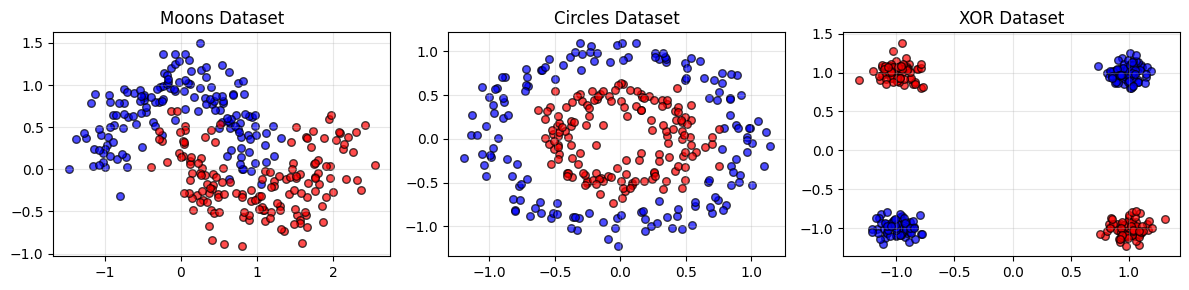

DECISION BOUNDARIES


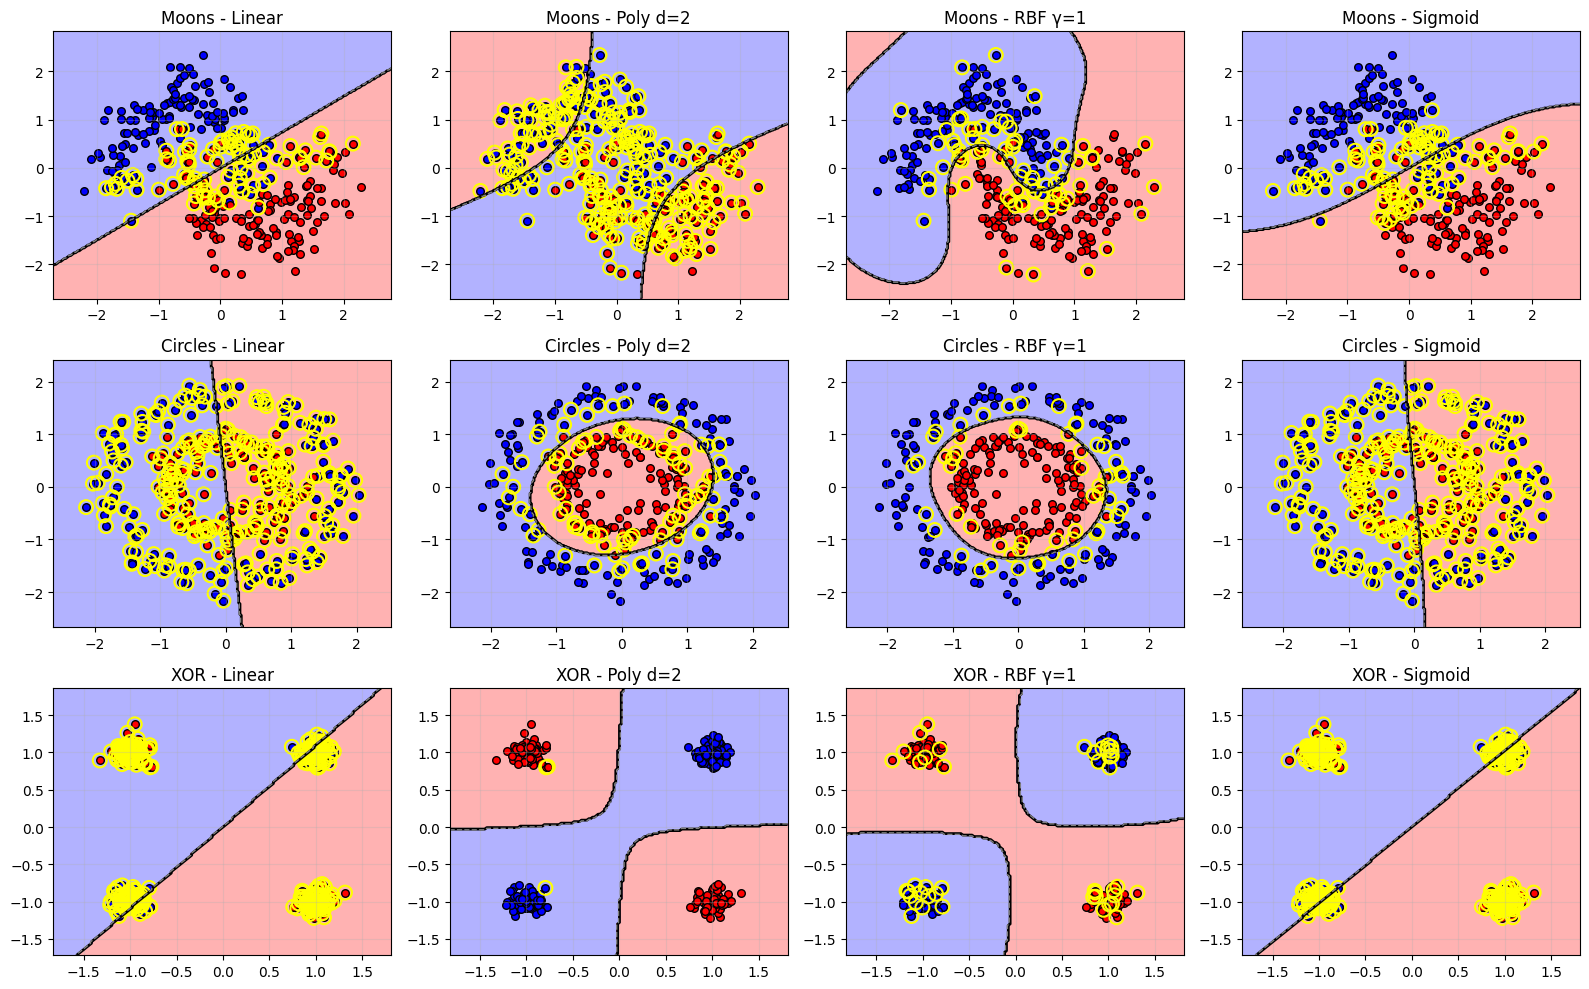


ACCURACY COMPARISON
Dataset    | Linear | Poly2 | Poly3 | Poly4 | RBF0.1 | RBF1 | RBF10 | Sigmoid
------------------------------------------------------------------------------------------
Moons      | 0.900 | 0.533 | 0.900 | 0.478 | 0.900 | 0.989 | 0.956 | 0.889
Circles    | 0.400 | 1.000 | 0.489 | 0.933 | 1.000 | 1.000 | 1.000 | 0.244
XOR        | 0.633 | 1.000 | 0.444 | 1.000 | 1.000 | 1.000 | 1.000 | 0.678

SUMMARY
1. Linear: Fails on non-linear data (Circles/XOR)
2. Polynomial: Needs right degree
3. RBF: Most versatile kernel
4. Small C: Wider margin
5. Large gamma: Overfitting
6. Support vectors define boundary

PART F: SUPPORT VECTOR MACHINES

Training One-vs-One SVM...
One-vs-One Accuracy: 0.9833333333333333
Training Time: 0.3659553527832031

Training One-vs-Rest SVM...
One-vs-Rest Accuracy: 0.9833333333333333
Training Time: 0.264056921005249

Running GridSearchCV for SVM...
Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best SVM Accuracy: 0.9805555555555555

Train

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# =========================
# Part A: Data Generation
# =========================

X_m, y_m = make_moons(300, noise=0.2, random_state=42)
y_m = 2*y_m - 1

X_c, y_c = make_circles(300, noise=0.1, random_state=42, factor=0.5)
y_c = 2*y_c - 1

X_x = np.random.randn(300,2)*0.1
y_x = np.array([-1]*75+[1]*75+[-1]*75+[1]*75)

X_x[:75] += [1,1]
X_x[75:150] += [-1,1]
X_x[150:225] += [-1,-1]
X_x[225:] += [1,-1]

idx = np.random.permutation(300)
X_x, y_x = X_x[idx], y_x[idx]

fig, ax = plt.subplots(1,3,figsize=(12,3))

for i,(X,y,n) in enumerate([(X_m,y_m,'Moons'),(X_c,y_c,'Circles'),(X_x,y_x,'XOR')]):
    ax[i].scatter(X[y==-1,0],X[y==-1,1],c='blue',alpha=0.7,edgecolors='k',s=30)
    ax[i].scatter(X[y==1,0],X[y==1,1],c='red',alpha=0.7,edgecolors='k',s=30)
    ax[i].set_title(f'{n} Dataset')
    ax[i].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

# =========================
# Part B: SVM Implementation
# =========================

class SVM:

    def __init__(self,C=1,kernel='linear',d=3,g='auto',c0=0):
        self.C,self.k,self.d,self.g,self.c0 = C,kernel,d,g,c0
        self.a,self.b,self.sv,self.sv_y = None,0,None,None

    def _ker(self,X1,X2):

        if self.k=='linear':
            return X1@X2.T

        elif self.k=='poly':
            return (self.g*(X1@X2.T)+self.c0)**self.d

        elif self.k=='rbf':
            d = np.sum(X1**2,1)[:,None] + np.sum(X2**2,1) - 2*X1@X2.T
            return np.exp(-self.g*d)

        elif self.k=='sigmoid':
            return np.tanh(self.g*(X1@X2.T)+self.c0)

        return X1@X2.T

    def fit(self,X,y):

        n = X.shape[0]

        self.g = 1.0/(X.shape[1]*X.var()) if self.g=='auto' else self.g

        K = self._ker(X,X)

        self.a = np.zeros(n)
        self.b = 0

        # Simplified training
        for _ in range(50):

            for i in range(n):

                g_i = np.sum(self.a*y*K[i]) + self.b

                if y[i]*g_i < 1 and self.a[i] < self.C:
                    self.a[i] += 0.1
                    self.b += y[i]*0.01

                elif y[i]*g_i > 1 and self.a[i] > 0:
                    self.a[i] -= 0.1
                    self.b -= y[i]*0.01

        sv_idx = self.a > 1e-3

        self.sv = X[sv_idx]
        self.sv_y = y[sv_idx]
        self.a = self.a[sv_idx]

        if len(self.a) > 0:
            self.b = np.mean(self.sv_y - self._ker(self.sv,self.sv)@(self.a*self.sv_y))

        return self

    def predict(self,X):

        if self.sv is None or len(self.sv)==0:
            return np.zeros(X.shape[0])

        return np.sign(self._ker(X,self.sv)@(self.a*self.sv_y)+self.b)

    def score(self,X,y):
        return accuracy_score(y,self.predict(X))


# =========================
# Part C: Visualization
# =========================

print("="*50+"\nDECISION BOUNDARIES\n"+"="*50)

kernels=[
('Linear',{'kernel':'linear'}),
('Poly d=2',{'kernel':'poly','d':2,'g':1}),
('RBF γ=1',{'kernel':'rbf','g':1}),
('Sigmoid',{'kernel':'sigmoid','g':0.1})
]

datasets=[
('Moons',X_m,y_m),
('Circles',X_c,y_c),
('XOR',X_x,y_x)
]

fig,ax = plt.subplots(3,4,figsize=(16,10))

for r,(dn,X,y) in enumerate(datasets):

    Xs = StandardScaler().fit_transform(X)

    h=0.02
    x1,x2 = Xs[:,0].min()-0.5, Xs[:,0].max()+0.5
    y1,y2 = Xs[:,1].min()-0.5, Xs[:,1].max()+0.5

    xx,yy = np.meshgrid(np.arange(x1,x2,h),np.arange(y1,y2,h))

    for c,(kn,prm) in enumerate(kernels):

        svm = SVM(**prm).fit(Xs,y)

        Z = svm.predict(np.c_[xx.ravel(),yy.ravel()])
        Z = Z.reshape(xx.shape)

        ax[r,c].contourf(xx,yy,Z,alpha=0.3,colors=['blue','red'])
        ax[r,c].contour(xx,yy,Z,levels=[0],colors='k',linewidths=2)
        ax[r,c].contour(xx,yy,Z,levels=[-1,1],colors='gray',linestyles='--',linewidths=1)

        ax[r,c].scatter(Xs[y==-1,0],Xs[y==-1,1],c='blue',edgecolors='k',s=30)
        ax[r,c].scatter(Xs[y==1,0],Xs[y==1,1],c='red',edgecolors='k',s=30)

        if svm.sv is not None and len(svm.sv)>0:
            ax[r,c].scatter(svm.sv[:,0],svm.sv[:,1],
                            s=100,facecolors='none',
                            edgecolors='yellow',linewidths=1.5)

        ax[r,c].set_title(f'{dn} - {kn}')
        ax[r,c].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

# =========================
# Accuracy Comparison
# =========================

print("\n"+"="*50+"\nACCURACY COMPARISON\n"+"="*50)

all_kernels=[
('Linear',{'kernel':'linear'}),
('Poly2',{'kernel':'poly','d':2,'g':1}),
('Poly3',{'kernel':'poly','d':3,'g':1}),
('Poly4',{'kernel':'poly','d':4,'g':1}),
('RBF0.1',{'kernel':'rbf','g':0.1}),
('RBF1',{'kernel':'rbf','g':1}),
('RBF10',{'kernel':'rbf','g':10}),
('Sigmoid',{'kernel':'sigmoid','g':0.1})
]

print(f"{'Dataset':10} | {' | '.join([k[0] for k in all_kernels])}")
print("-" * 90)

for dn,X,y in datasets:

    X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.3,random_state=42)

    scaler = StandardScaler()
    X_trs = scaler.fit_transform(X_tr)
    X_tes = scaler.transform(X_te)

    accs=[]

    for kn,prm in all_kernels:
        acc = SVM(**prm).fit(X_trs,y_tr).score(X_tes,y_te)
        accs.append(f"{acc:.3f}")

    print(f"{dn:10} | {' | '.join(accs)}")

print("\n"+"="*50+"\nSUMMARY\n"+"="*50)

print("1. Linear: Fails on non-linear data (Circles/XOR)")
print("2. Polynomial: Needs right degree")
print("3. RBF: Most versatile kernel")
print("4. Small C: Wider margin")
print("5. Large gamma: Overfitting")
print("6. Support vectors define boundary")







##############POST LAB##########################################
# ============================================
# PART F: SUPPORT VECTOR MACHINES (SVM)
# ============================================
# ============================================
# Load Dataset and Train-Test Split
# ============================================

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.svm import SVC
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import numpy as np
import time

print("\n" + "="*50)
print("PART F: SUPPORT VECTOR MACHINES")
print("="*50)


# ============================================
# Feature Scaling (Important for SVM)
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================
# 1️⃣ One-vs-One SVM
# ============================================

print("\nTraining One-vs-One SVM...")

start = time.time()

svm_ovo = OneVsOneClassifier(SVC(kernel='rbf'))

svm_ovo.fit(X_train_scaled, y_train)

y_pred_ovo = svm_ovo.predict(X_test_scaled)

ovo_time = time.time() - start

ovo_acc = accuracy_score(y_test, y_pred_ovo)

print("One-vs-One Accuracy:", ovo_acc)
print("Training Time:", ovo_time)


# ============================================
# 2️⃣ One-vs-Rest SVM
# ============================================

print("\nTraining One-vs-Rest SVM...")

start = time.time()

svm_ovr = OneVsRestClassifier(SVC(kernel='rbf'))

svm_ovr.fit(X_train_scaled, y_train)

y_pred_ovr = svm_ovr.predict(X_test_scaled)

ovr_time = time.time() - start

ovr_acc = accuracy_score(y_test, y_pred_ovr)

print("One-vs-Rest Accuracy:", ovr_acc)
print("Training Time:", ovr_time)


# ============================================
# 3️⃣ Hyperparameter Tuning using GridSearchCV
# ============================================

print("\nRunning GridSearchCV for SVM...")

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf', 'poly']
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_

print("Best Parameters:", grid_svm.best_params_)

y_pred_best = best_svm.predict(X_test_scaled)

best_acc = accuracy_score(y_test, y_pred_best)

print("Best SVM Accuracy:", best_acc)


# ============================================
# 4️⃣ Custom Kernel Function
# ============================================

print("\nTraining SVM with Custom Kernel...")

def custom_kernel(X, Y):

    # Example: polynomial-like custom kernel
    return (np.dot(X, Y.T) + 1) ** 2

svm_custom = SVC(kernel=custom_kernel)

svm_custom.fit(X_train_scaled, y_train)

y_pred_custom = svm_custom.predict(X_test_scaled)

custom_acc = accuracy_score(y_test, y_pred_custom)

print("Custom Kernel Accuracy:", custom_acc)


# ============================================
# 5️⃣ Neural Network for Comparison
# ============================================

print("\nTraining Neural Network (MLP)...")

start = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

mlp_time = time.time() - start

mlp_acc = accuracy_score(y_test, y_pred_mlp)

print("Neural Network Accuracy:", mlp_acc)
print("Training Time:", mlp_time)


# ============================================
# 6️⃣ Final Comparison
# ============================================

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

print(f"SVM One-vs-One Accuracy: {ovo_acc:.4f}")
print(f"SVM One-vs-Rest Accuracy: {ovr_acc:.4f}")
print(f"Tuned SVM Accuracy: {best_acc:.4f}")
print(f"Custom Kernel SVM Accuracy: {custom_acc:.4f}")
print(f"Neural Network Accuracy: {mlp_acc:.4f}")

print("\nDetailed Report for Best SVM Model:")
print(classification_report(y_test, y_pred_best))

